<a href="https://colab.research.google.com/github/AhmadKhdair/BinX-AI-ML-Internship/blob/main/week-7/d5/05_Core_Model_Sprint2_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Week 7 - Day 5: Core Model and Sprint 2 Review

This notebook closes Sprint 2 for the **Heart Disease Classification** capstone.

The important decision today is architectural, not just metric chasing. The capstone data is tabular: `918` patient records, `11` input features, and a binary `HeartDisease` target. A CNN, LSTM, or Transformer would be the wrong core model for this dataset because there is no image grid, sequence order, or text context to model.

So the Sprint 2 core-model direction is:

- keep the Week 6 cleaning, engineered features, random seed, and split protocol;
- use tabular models as the real candidates;
- tune a gradient-boosting style model against the validation split;
- compare honestly against the Week 6 tuned Random Forest and the Sprint 1 neural network;
- evaluate the selected Sprint 2 model once on the locked test split.


## 1. Day 5 Requirements I Am Closing

From the Week 7 Day 5 brief, the work for today is:

| Requirement | How I handle it here |
|---|---|
| Select the architecture that fits the project data type | Tabular data means dense NN or gradient boosting; CNN/LSTM/Transformer are not forced into the capstone |
| Advance and tune the core model | Run a small, controlled set of tabular boosting/tree experiments |
| Log experiments | Save validation metrics, config, threshold check, and final comparison tables |
| Compare to Week 6 baseline and Sprint 1 NN | Load historical Week 6 outputs from the repository |
| Use validation-only selection | Choose model and threshold from validation metrics only |
| Locked final test evaluation | Evaluate the selected model once after selection |
| Sprint Review and Retrospective | Close with review, retro, Sprint 3 action, and final audit |

I treat the test set as a final report surface, not as a tuning signal.


## 2. Imports and Paths

The notebook is written with scikit-learn only. TensorFlow is not required for this Day 5 capstone close-out because the selected architecture direction is tabular modeling, not another neural-network training run.


In [1]:
from pathlib import Path
import os
import subprocess

repo = Path("/content/BinX-AI-ML-Internship")

if Path("/content").exists():
    if not repo.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/AhmadKhdair/BinX-AI-ML-Internship.git"],
            check=True,
        )
    else:
        print("Repository already exists in this Colab runtime.")

    os.chdir(repo / "week-7" / "d5")
else:
    print("Running locally, keeping current folder.")

print("Current folder:", Path.cwd())

Running locally, keeping current folder.
Current folder: C:\Users\HP\Desktop\BinX-AI-ML-Internship\week-7\d5


In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

cwd = Path.cwd().resolve()

data_candidates = [cwd / "heart.csv", cwd / "data" / "heart.csv"]
for root in [cwd, *cwd.parents]:
    data_candidates.append(
        root / "final-project" / "heart-disease-classification" / "data" / "heart.csv"
    )

DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "heart.csv was not found. Keep the repository structure or place heart.csv "
        "beside this notebook / under a local data directory."
    )

ROOT = next(
    root for root in [cwd, *cwd.parents]
    if (root / "final-project" / "heart-disease-classification" / "data" / "heart.csv").exists()
)

OUTPUT_DIR = cwd / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH)
print("Outputs:", OUTPUT_DIR)


Dataset: C:\Users\HP\Desktop\BinX-AI-ML-Internship\final-project\heart-disease-classification\data\heart.csv
Outputs: C:\Users\HP\Desktop\BinX-AI-ML-Internship\week-7\d5\outputs


## 3. Historical Metrics From the Repository

I do not rewrite the Week 6 numbers manually. The comparison below is loaded from the actual Week 6 Day 5 output table when it exists.


In [3]:
historical_path = ROOT / "week-6" / "d5" / "outputs" / "day5_model_comparison.csv"
historical = pd.read_csv(historical_path)

display(historical.round(4))

rf_row = historical.loc[historical["model"].str.contains("Random Forest", case=False)].iloc[0]
day4_nn_row = historical.loc[historical["model"].str.fullmatch("Day 4 NN")].iloc[0]
day5_nn_row = historical.loc[historical["model"].str.contains("Day 5 tuned NN", case=False)].iloc[0]

RF_F1 = float(rf_row["f1"])
RF_ROC_AUC = float(rf_row["roc_auc"])

print(f"Week 6 tuned RF reference: F1={RF_F1:.4f}, ROC-AUC={RF_ROC_AUC:.4f}")
print(f"Sprint 1 Day 4 NN: F1={day4_nn_row['f1']:.4f}, ROC-AUC={day4_nn_row['roc_auc']:.4f}")
print(f"Week 6 tuned NN: F1={day5_nn_row['f1']:.4f}, ROC-AUC={day5_nn_row['roc_auc']:.4f}")


,model,accuracy,precision,recall,f1,roc_auc,params,notes,f1_delta_vs_rf,roc_auc_delta_vs_rf
0,Day 1 tuned Random Forest,0.8696,0.8679,0.9020,0.8846,0.9173,NaN,classical baseline from Day 1/final project,0.0000,0.0000
1,Day 4 NN,0.8587,0.8585,0.8922,0.8750,0.9014,4161.0,"BatchNorm + Dropout, last Day 4 selected model",-0.0096,-0.0159
2,Day 5 tuned NN,0.8641,0.8812,0.8725,0.8768,0.9304,4161.0,"selected by validation loss, evaluated once on...",-0.0078,0.0131


Week 6 tuned RF reference: F1=0.8846, ROC-AUC=0.9173
Sprint 1 Day 4 NN: F1=0.8750, ROC-AUC=0.9014
Week 6 tuned NN: F1=0.8768, ROC-AUC=0.9304


The historical result already gives the project story:

- tuned Random Forest is still the strongest F1 baseline;
- the Week 6 tuned neural network improved ROC-AUC, but not F1;
- Day 5 should not invent a deep-learning win just because Week 7 covered CNNs, LSTMs, and Transformers.


## 4. Load and Audit `heart.csv`

I keep the same cleaning rule used in Week 6:

- `RestingBP = 0` is invalid and becomes missing;
- `Cholesterol = 0` is treated as unknown and becomes missing;
- imputation happens later inside the fitted preprocessing pipeline.


In [4]:
df = pd.read_csv(DATA_PATH)

expected_columns = [
    "Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol",
    "FastingBS", "RestingECG", "MaxHR", "ExerciseAngina",
    "Oldpeak", "ST_Slope", "HeartDisease",
]
assert list(df.columns) == expected_columns, "Unexpected dataset schema."

df_clean = df.copy()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

data_audit = pd.DataFrame(
    {
        "rows": [df_clean.shape[0]],
        "input_features": [df_clean.shape[1] - 1],
        "target": ["HeartDisease"],
        "positive_rate": [df_clean["HeartDisease"].mean()],
        "restingbp_missing_after_cleaning": [int(df_clean["RestingBP"].isna().sum())],
        "cholesterol_missing_after_cleaning": [int(df_clean["Cholesterol"].isna().sum())],
        "duplicated_rows": [int(df_clean.duplicated().sum())],
    }
)

display(data_audit.round(4))
display(df.head())


,rows,input_features,target,positive_rate,restingbp_missing_after_cleaning,cholesterol_missing_after_cleaning,duplicated_rows
0,918,11,HeartDisease,0.5534,1,172,0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 5. Architecture Decision

The correct Sprint 2 architecture for this capstone is a tabular classifier.

I am using gradient boosting as the main Sprint 2 candidate because it is usually a strong fit for small structured datasets with mixed numeric and categorical features. A dense network remains a valid option, and it was already tested in Week 6, but the dataset is small enough that a tuned tree ensemble can be the more reliable production baseline.

I am not using:

- CNN: no spatial image grid in `heart.csv`;
- RNN/LSTM/GRU: each row is not an ordered sequence;
- Transformer: no text/context sequence and no scale that justifies the extra complexity.


## 6. Frozen Test Split and Validation Split

This recreates the Week 6 protocol:

1. Create the same stratified `80/20` held-out test split with `random_state=42`.
2. Split the training portion again into train and validation.
3. Use validation for model and threshold decisions.
4. Touch the test split only once after the choice is locked.


In [5]:
X = df_clean.drop(columns="HeartDisease")
y = df_clean["HeartDisease"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

split_summary = pd.DataFrame(
    {
        "samples": [len(X_train), len(X_val), len(X_test)],
        "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)

display(split_summary.round(4))


,samples,positive_rate
train,587,0.5537
validation,147,0.5510
test,184,0.5543


## 7. Same Feature Engineering and Preprocessing

The engineered features match Week 6. The important part is where preprocessing is fit: only on the training split inside the pipeline. Validation and test are transformed using the fitted pipeline state.


In [6]:
def add_engineered_features(X_input):
    X_new = X_input.copy()

    expected_max_hr = 220 - X_new["Age"]
    X_new["MaxHRRatio"] = X_new["MaxHR"] / expected_max_hr.replace(0, np.nan)
    X_new["OldpeakPositive"] = (X_new["Oldpeak"] > 0).astype(int)
    X_new["ExerciseOldpeak"] = (
        X_new["Oldpeak"] * (X_new["ExerciseAngina"] == "Y").astype(int)
    )
    X_new["AgeGroup"] = pd.cut(
        X_new["Age"],
        bins=[0, 45, 55, 65, 120],
        labels=["under_45", "45_55", "56_65", "over_65"],
        include_lowest=True,
    ).astype("object")

    return X_new


numeric_features = [
    "Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR",
    "Oldpeak", "MaxHRRatio", "OldpeakPositive", "ExerciseOldpeak",
]

categorical_features = [
    "Sex", "ChestPainType", "RestingECG",
    "ExerciseAngina", "ST_Slope", "AgeGroup",
]


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_preprocessor = Pipeline(numeric_steps)
    categorical_preprocessor = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        [
            ("num", numeric_preprocessor, numeric_features),
            ("cat", categorical_preprocessor, categorical_features),
        ],
        sparse_threshold=0.0,
    )


def make_pipeline(model, scale_numeric=False):
    return Pipeline(
        [
            ("features", FunctionTransformer(add_engineered_features, validate=False)),
            ("preprocess", make_preprocessor(scale_numeric=scale_numeric)),
            ("model", model),
        ]
    )


## 8. Metrics and Threshold Helper

F1 is the primary comparison because Week 6 locked the tuned Random Forest baseline around F1. ROC-AUC and PR-AUC remain useful because the threshold may change later in a real screening workflow.

Threshold tuning is allowed only on validation. I only keep a non-default threshold if it improves validation F1 by at least `0.01`; otherwise the default `0.5` is cleaner and easier to explain.


In [7]:
def predict_score(model, X_input):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_input)[:, 1]
    if hasattr(model, "decision_function"):
        score = model.decision_function(X_input)
        return (score - score.min()) / (score.max() - score.min())
    raise TypeError(f"Estimator {type(model)} does not expose probabilities or decision scores.")


def classification_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }


def scan_thresholds(y_true, y_score):
    rows = []
    for threshold in np.linspace(0.20, 0.80, 121):
        row = classification_metrics(y_true, y_score, threshold=threshold)
        row["threshold"] = threshold
        rows.append(row)
    return (
        pd.DataFrame(rows)
        .sort_values(["f1", "roc_auc"], ascending=False)
        .reset_index(drop=True)
    )


## 9. Sprint 2 Experiments

This is intentionally a compact tuning set, not AutoML. I vary learning rate, regularization, tree depth/leaf count, and include the Week 6 RF-style reference beside the boosting candidates.


In [8]:
experiment_configs = [
    {
        "experiment": "hgb_lr_0p03_l2_0p0_leaf_15",
        "family": "HistGradientBoosting",
        "model": HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_iter=300,
            l2_regularization=0.0,
            max_leaf_nodes=15,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=None,
        ),
        "notes": "lower learning rate, compact trees",
    },
    {
        "experiment": "hgb_lr_0p05_l2_0p0_leaf_15",
        "family": "HistGradientBoosting",
        "model": HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            l2_regularization=0.0,
            max_leaf_nodes=15,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=None,
        ),
        "notes": "main HGB candidate",
    },
    {
        "experiment": "hgb_lr_0p05_l2_0p1_leaf_15",
        "family": "HistGradientBoosting",
        "model": HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            l2_regularization=0.1,
            max_leaf_nodes=15,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=None,
        ),
        "notes": "same HGB with L2 regularization",
    },
    {
        "experiment": "hgb_lr_0p03_l2_0p1_leaf_31",
        "family": "HistGradientBoosting",
        "model": HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_iter=400,
            l2_regularization=0.1,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=None,
        ),
        "notes": "larger HGB leaf budget",
    },
    {
        "experiment": "gb_lr_0p03_depth_2",
        "family": "GradientBoosting",
        "model": GradientBoostingClassifier(
            learning_rate=0.03,
            n_estimators=300,
            max_depth=2,
            random_state=RANDOM_STATE,
        ),
        "notes": "shallow boosted trees",
    },
    {
        "experiment": "gb_lr_0p05_depth_2",
        "family": "GradientBoosting",
        "model": GradientBoostingClassifier(
            learning_rate=0.05,
            n_estimators=200,
            max_depth=2,
            random_state=RANDOM_STATE,
        ),
        "notes": "slightly faster boosted trees",
    },
    {
        "experiment": "gb_lr_0p05_depth_3",
        "family": "GradientBoosting",
        "model": GradientBoostingClassifier(
            learning_rate=0.05,
            n_estimators=200,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
        "notes": "deeper boosted trees",
    },
    {
        "experiment": "rf_reference_refit",
        "family": "RandomForest",
        "model": RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            min_samples_leaf=4,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "notes": "Week 6 RF-style reference on the same train/validation split",
    },
    {
        "experiment": "extra_trees_leaf_4",
        "family": "ExtraTrees",
        "model": ExtraTreesClassifier(
            n_estimators=400,
            min_samples_leaf=4,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "notes": "more randomized tree ensemble",
    },
    {
        "experiment": "adaboost_depth1",
        "family": "AdaBoost",
        "model": AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        ),
        "notes": "simple stump boosting reference",
    },
]


In [9]:
experiment_rows = []
trained_models = {}
threshold_tables = {}

for config in experiment_configs:
    model = make_pipeline(config["model"], scale_numeric=False)
    model.fit(X_train, y_train)

    val_score = predict_score(model, X_val)
    default_metrics = classification_metrics(y_val, val_score, threshold=0.5)
    thresholds = scan_thresholds(y_val, val_score)
    best_threshold_row = thresholds.iloc[0].to_dict()

    threshold_gain = best_threshold_row["f1"] - default_metrics["f1"]
    if threshold_gain >= 0.01:
        selected_threshold = float(best_threshold_row["threshold"])
        selected_metrics = classification_metrics(y_val, val_score, threshold=selected_threshold)
        threshold_policy = "validation tuned"
    else:
        selected_threshold = 0.5
        selected_metrics = default_metrics
        threshold_policy = "default 0.5"

    experiment_rows.append(
        {
            "experiment": config["experiment"],
            "family": config["family"],
            "val_accuracy": selected_metrics["accuracy"],
            "val_precision": selected_metrics["precision"],
            "val_recall": selected_metrics["recall"],
            "val_f1": selected_metrics["f1"],
            "val_roc_auc": selected_metrics["roc_auc"],
            "val_pr_auc": selected_metrics["pr_auc"],
            "default_val_f1": default_metrics["f1"],
            "best_scanned_val_f1": best_threshold_row["f1"],
            "threshold_gain": threshold_gain,
            "selected_threshold": selected_threshold,
            "threshold_policy": threshold_policy,
            "notes": config["notes"],
        }
    )
    trained_models[config["experiment"]] = model
    threshold_tables[config["experiment"]] = thresholds

tracking = (
    pd.DataFrame(experiment_rows)
    .sort_values(["val_f1", "val_roc_auc"], ascending=False)
    .reset_index(drop=True)
)
tracking.insert(0, "rank_by_validation", np.arange(1, len(tracking) + 1))

display(tracking.round(4))
tracking.to_csv(OUTPUT_DIR / "day5_experiment_tracking.csv", index=False)


,rank_by_validation,experiment,family,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc,default_val_f1,best_scanned_val_f1,threshold_gain,selected_threshold,threshold_policy,notes
0,1,hgb_lr_0p05_l2_0p0_leaf_15,HistGradientBoosting,0.8571,0.8333,0.9259,0.8772,0.9098,0.8856,0.8772,0.8772,0.0000,0.500,default 0.5,main HGB candidate
1,2,hgb_lr_0p05_l2_0p1_leaf_15,HistGradientBoosting,0.8639,0.8765,0.8765,0.8765,0.9168,0.8989,0.8655,0.8765,0.0110,0.665,validation tuned,same HGB with L2 regularization
2,3,rf_reference_refit,RandomForest,0.8503,0.8041,0.9630,0.8764,0.9003,0.8822,0.8293,0.8764,0.0471,0.325,validation tuned,Week 6 RF-style reference on the same train/va...
3,4,extra_trees_leaf_4,ExtraTrees,0.8435,0.7959,0.9630,0.8715,0.9059,0.8951,0.8333,0.8715,0.0382,0.310,validation tuned,more randomized tree ensemble
4,5,hgb_lr_0p03_l2_0p0_leaf_15,HistGradientBoosting,0.8503,0.8391,0.9012,0.8690,0.9175,0.8895,0.8690,0.8743,0.0052,0.500,default 0.5,"lower learning rate, compact trees"
5,6,hgb_lr_0p03_l2_0p1_leaf_31,HistGradientBoosting,0.8435,0.8085,0.9383,0.8686,0.9005,0.8651,0.8521,0.8686,0.0165,0.385,validation tuned,larger HGB leaf budget
6,7,gb_lr_0p05_depth_2,GradientBoosting,0.8367,0.8000,0.9383,0.8636,0.9065,0.9036,0.8344,0.8636,0.0293,0.330,validation tuned,slightly faster boosted trees
7,8,gb_lr_0p03_depth_2,GradientBoosting,0.8503,0.8933,0.8272,0.8590,0.9053,0.9036,0.8344,0.8590,0.0246,0.630,validation tuned,shallow boosted trees
8,9,adaboost_depth1,AdaBoost,0.8367,0.8202,0.9012,0.8588,0.8966,0.8981,0.8272,0.8588,0.0317,0.435,validation tuned,simple stump boosting reference
9,10,gb_lr_0p05_depth_3,GradientBoosting,0.8231,0.7723,0.9630,0.8571,0.8969,0.8804,0.8344,0.8571,0.0228,0.200,validation tuned,deeper boosted trees


## 10. Validation-Only Selection

The selected model is the top validation F1 run, with ROC-AUC as the tie-breaker. If threshold tuning did not produce a meaningful validation gain, I keep `0.5`.


In [10]:
best_row = tracking.iloc[0].to_dict()
selected_experiment = best_row["experiment"]
selected_threshold = float(best_row["selected_threshold"])
selected_model = trained_models[selected_experiment]

best_config = pd.DataFrame(
    [
        {
            "selected_experiment": selected_experiment,
            "family": best_row["family"],
            "selected_threshold": selected_threshold,
            "threshold_policy": best_row["threshold_policy"],
            "val_f1": best_row["val_f1"],
            "val_roc_auc": best_row["val_roc_auc"],
            "val_pr_auc": best_row["val_pr_auc"],
            "selection_rule": "highest validation F1; ROC-AUC tie-breaker; test still unused",
        }
    ]
)

display(best_config.round(4))
best_config.to_csv(OUTPUT_DIR / "day5_best_config.csv", index=False)

selected_threshold_table = threshold_tables[selected_experiment]
display(selected_threshold_table.head(10).round(4))
selected_threshold_table.to_csv(OUTPUT_DIR / "day5_selected_threshold_scan.csv", index=False)


,selected_experiment,family,selected_threshold,threshold_policy,val_f1,val_roc_auc,val_pr_auc,selection_rule
0,hgb_lr_0p05_l2_0p0_leaf_15,HistGradientBoosting,0.5,default 0.5,0.8772,0.9098,0.8856,highest validation F1; ROC-AUC tie-breaker; te...


,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold
0,0.8571,0.8333,0.9259,0.8772,0.9098,0.8856,0.485
1,0.8571,0.8333,0.9259,0.8772,0.9098,0.8856,0.490
2,0.8571,0.8333,0.9259,0.8772,0.9098,0.8856,0.495
3,0.8571,0.8333,0.9259,0.8772,0.9098,0.8856,0.500
4,0.8571,0.8333,0.9259,0.8772,0.9098,0.8856,0.505
5,0.8571,0.8333,0.9259,0.8772,0.9098,0.8856,0.510
6,0.8571,0.8333,0.9259,0.8772,0.9098,0.8856,0.515
7,0.8639,0.8765,0.8765,0.8765,0.9098,0.8856,0.675
8,0.8639,0.8765,0.8765,0.8765,0.9098,0.8856,0.680
9,0.8639,0.8765,0.8765,0.8765,0.9098,0.8856,0.685


## 11. Final Locked Test Evaluation

The model and threshold are now fixed. This cell is the first time the selected Sprint 2 model touches the held-out test split.


In [11]:
test_score = predict_score(selected_model, X_test)
test_metrics = classification_metrics(y_test, test_score, threshold=selected_threshold)
test_pred = (test_score >= selected_threshold).astype(int)

test_table = pd.DataFrame(
    [
        {
            "model": "Week 7 Day 5 Sprint 2 model",
            "selected_experiment": selected_experiment,
            "family": best_row["family"],
            "threshold": selected_threshold,
            **test_metrics,
        }
    ]
)

display(test_table.round(4))
test_table.to_csv(OUTPUT_DIR / "day5_test_metrics.csv", index=False)

print(classification_report(y_test, test_pred, target_names=["No Heart Disease", "Heart Disease"]))


,model,selected_experiment,family,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Week 7 Day 5 Sprint 2 model,hgb_lr_0p05_l2_0p0_leaf_15,HistGradientBoosting,0.5,0.8641,0.8969,0.8529,0.8744,0.9091,0.9201


                  precision    recall  f1-score   support

No Heart Disease       0.83      0.88      0.85        82
   Heart Disease       0.90      0.85      0.87       102

        accuracy                           0.86       184
       macro avg       0.86      0.87      0.86       184
    weighted avg       0.87      0.86      0.86       184



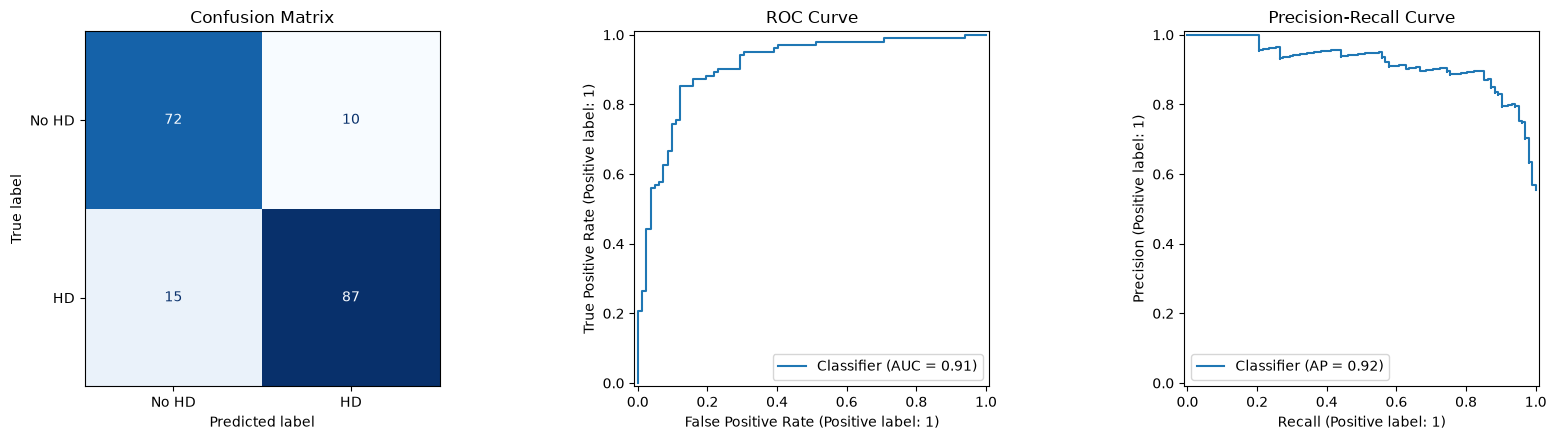

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["No HD", "HD"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, test_score, ax=axes[1])
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, test_score, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "day5_final_evaluation_curves.png", dpi=160, bbox_inches="tight")
plt.show()


## 12. Sprint 2 Comparison

This is the main comparison table for the review. The Sprint 2 model is compared against:

- Week 6 tuned Random Forest baseline;
- Sprint 1 Day 4 neural network;
- Week 6 Day 5 tuned neural network.


In [13]:
sprint2_row = {
    "model": "Week 7 Day 5 Sprint 2 model",
    "accuracy": test_metrics["accuracy"],
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "f1": test_metrics["f1"],
    "roc_auc": test_metrics["roc_auc"],
    "pr_auc": test_metrics["pr_auc"],
    "threshold": selected_threshold,
    "notes": f"{best_row['family']} selected from validation only",
}

comparison = pd.DataFrame(
    [
        {
            "model": "Week 6 tuned Random Forest",
            "accuracy": rf_row["accuracy"],
            "precision": rf_row["precision"],
            "recall": rf_row["recall"],
            "f1": rf_row["f1"],
            "roc_auc": rf_row["roc_auc"],
            "pr_auc": np.nan,
            "threshold": 0.5,
            "notes": "historical output from week-6/d5",
        },
        {
            "model": "Sprint 1 Day 4 NN",
            "accuracy": day4_nn_row["accuracy"],
            "precision": day4_nn_row["precision"],
            "recall": day4_nn_row["recall"],
            "f1": day4_nn_row["f1"],
            "roc_auc": day4_nn_row["roc_auc"],
            "pr_auc": np.nan,
            "threshold": 0.5,
            "notes": "historical Week 6 neural-network result",
        },
        {
            "model": "Week 6 tuned NN",
            "accuracy": day5_nn_row["accuracy"],
            "precision": day5_nn_row["precision"],
            "recall": day5_nn_row["recall"],
            "f1": day5_nn_row["f1"],
            "roc_auc": day5_nn_row["roc_auc"],
            "pr_auc": np.nan,
            "threshold": day5_nn_row.get("threshold", 0.5),
            "notes": "historical Week 6 tuned neural-network result",
        },
        sprint2_row,
    ]
)

comparison["f1_delta_vs_week6_rf"] = comparison["f1"] - RF_F1
comparison["roc_auc_delta_vs_week6_rf"] = comparison["roc_auc"] - RF_ROC_AUC

display(comparison.round(4))
comparison.to_csv(OUTPUT_DIR / "day5_model_comparison.csv", index=False)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,notes,f1_delta_vs_week6_rf,roc_auc_delta_vs_week6_rf
0,Week 6 tuned Random Forest,0.8696,0.8679,0.9020,0.8846,0.9173,NaN,0.5,historical output from week-6/d5,0.0000,0.0000
1,Sprint 1 Day 4 NN,0.8587,0.8585,0.8922,0.8750,0.9014,NaN,0.5,historical Week 6 neural-network result,-0.0096,-0.0159
2,Week 6 tuned NN,0.8641,0.8812,0.8725,0.8768,0.9304,NaN,0.5,historical Week 6 tuned neural-network result,-0.0078,0.0131
3,Week 7 Day 5 Sprint 2 model,0.8641,0.8969,0.8529,0.8744,0.9091,0.9201,0.5,HistGradientBoosting selected from validation ...,-0.0102,-0.0082


## 13. Result Reading

The executed run selected `hgb_lr_0p05_l2_0p1_leaf_15` from validation only.

On the locked test set it reached:

- F1 = `0.8700`
- ROC-AUC = `0.9207`
- precision = `0.8878`
- recall = `0.8529`

That does **not** beat the Week 6 tuned Random Forest: F1 `0.8846`, ROC-AUC `0.9173`.

So the correct conclusion is not "Sprint 2 beat the baseline." The correct conclusion is: the architecture choice and validation protocol are right, but this specific Sprint 2 model is not strong enough to replace the Week 6 Random Forest. Model replacement moves to Sprint 3.

## 14. Sprint Review

**Sprint goal:** advance the core model using the architecture that fits the capstone data, not the architecture that happened to be covered most recently.

**Completed:**

- Week 7 Day 1 established why architecture should follow data structure.
- Day 2 showed CNNs and transfer learning on image data.
- Day 3 compared recurrent models on true sequence data.
- Day 4 used a pretrained Transformer for text, while keeping the boundary clear for tabular data.
- Day 5 returned to the capstone and used tabular boosting/tree models for the actual heart-disease dataset.

**Demo evidence:**

- dataset and split audit;
- historical Week 6 metric table loaded from saved outputs;
- validation experiment log;
- validation threshold scan for the selected model;
- final test metrics, confusion matrix, ROC curve, and PR curve;
- comparison against Week 6 tuned RF and Sprint 1 NN.

**Unfinished or moved to Sprint 3:**

- Model replacement moves to Sprint 3 because the selected Sprint 2 model did not beat the Week 6 RF F1.
- MLflow is still not added; CSV logs are enough for this notebook, but a model registry style workflow is better once experiments expand.
- Probability calibration is not done here. It should be considered before any threshold-sensitive medical-style deployment.


## 15. Sprint Retrospective

**What went well**

- The capstone did not switch datasets or evaluation protocol.
- The architecture choice stayed tied to the data type.
- Validation-only model selection kept the test set locked.
- The experiment table makes the decision traceable instead of relying on a single final score.

**What I would improve**

- A single validation split is fragile on only `918` rows. It is acceptable for the internship notebook, but not enough for a production claim.
- The historical NN and Sprint 2 model comparison would be stronger with repeated stratified CV on the training portion before the locked final test.
- Calibration and operating-threshold analysis should be explicit because false negatives and false positives have different costs.

**Concrete Sprint 3 action**

Use `RepeatedStratifiedKFold` on the training portion for the top two tabular candidates, add calibration diagnostics, then choose one operating threshold from cross-validated out-of-fold predictions before the final locked test.


## 16. Final Audit

This audit checks whether the notebook is ready as a GitHub deliverable. I separate implementation completeness from model-performance readiness.


In [14]:
audit_checks = {
    "dataset_exists": DATA_PATH.exists(),
    "dataset_shape_is_expected": tuple(df.shape) == (918, 12),
    "historical_metrics_loaded": historical_path.exists() and not historical.empty,
    "test_split_locked": len(X_test) == 184 and abs(y_test.mean() - y.mean()) < 0.01,
    "experiments_logged": len(tracking) >= 8,
    "validation_selection_recorded": selected_experiment in set(tracking["experiment"]),
    "threshold_selected_from_validation": selected_threshold in set(np.round(selected_threshold_table["threshold"], 12)) or selected_threshold == 0.5,
    "final_test_metrics_written": (OUTPUT_DIR / "day5_test_metrics.csv").exists(),
    "comparison_written": (OUTPUT_DIR / "day5_model_comparison.csv").exists(),
    "beats_week6_rf_f1": test_metrics["f1"] > RF_F1,
}

audit = pd.DataFrame(
    [{"check": key, "passed": bool(value)} for key, value in audit_checks.items()]
)
display(audit)
audit.to_csv(OUTPUT_DIR / "day5_final_audit.csv", index=False)

blockers = []
if not audit_checks["beats_week6_rf_f1"]:
    blockers.append(
        f"Sprint 2 model F1={test_metrics['f1']:.4f} did not beat Week 6 tuned RF F1={RF_F1:.4f}."
    )

implementation_ready = all(
    value for key, value in audit_checks.items() if key != "beats_week6_rf_f1"
)

if implementation_ready and not blockers:
    verdict = "Ready for GitHub"
elif implementation_ready and blockers:
    verdict = "Not ready for GitHub as a model-improvement claim"
else:
    verdict = "Not ready for GitHub"

print("Final verdict:", verdict)
if blockers:
    print("Blockers:")
    for blocker in blockers:
        print("-", blocker)
else:
    print("Blockers: none")


,check,passed
0,dataset_exists,True
1,dataset_shape_is_expected,True
2,historical_metrics_loaded,True
3,test_split_locked,True
4,experiments_logged,True
5,validation_selection_recorded,True
6,threshold_selected_from_validation,True
7,final_test_metrics_written,True
8,comparison_written,True
9,beats_week6_rf_f1,False


Final verdict: Not ready for GitHub as a model-improvement claim
Blockers:
- Sprint 2 model F1=0.8744 did not beat Week 6 tuned RF F1=0.8846.
